# Tutorial 3: A one-asset HANK model

In this notebook we solve the one-asset HANK model from Auclert, Bardóczy, Rognlie, Straub (2021): "Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models" ([link to paper](https://www.bencebardoczy.com/publication/sequence-jacobian/sequence-jacobian.pdf)).

New concepts:
- **Hetinputs and hetoutputs**: adapt off-the-shelf HA blocks to new macro models.
- **Calibration DAG**: exploit analytical part of internal calibration 

For more examples and information on the SSJ toolkit, please visit our [GitHub page](https://github.com/shade-econ/sequence-jacobian).

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sequence_jacobian import simple, create_model  # functions
from sequence_jacobian import hetblocks, grids      # modules

## 1 Model description

The model is a HA version of the textbook New Keynesian model. Technology is linear in labor, prices are sticky á la Rotemberg, and monetary policy follows a Taylor rule. The model can be summarized in sequence form as

$$
\textbf{F}_t(\textbf{X}, Z) \equiv 
\begin{pmatrix}
Y_t - Z_t L_t
\\
Y_t \left[1 - \frac{\mu}{\mu-1}\frac{1}{2\kappa} \log(1 + \pi_t)^2\right] - w_t L_t - d_t
\\
r_t B - \tau_t
\\
r^*_t + \phi \pi_t - i_t
\\
1 + r_t - \frac{1+i_{t-1}}{1+\pi_t}
\\
\kappa \left(\frac{w_t}{Z_t} - \frac{1}{\mu} \right)  + \frac{1}{1+r_{t+1}} \frac{Y_{t+1}}{Y_t} \log(1+\pi_{t+1}) - \log(1+\pi_t)
\\
\mathcal{A}_t(\{r_s, w_s, \tau_s, d_s\})  - B
\\
\mathcal{N}_t(\{r_s, w_s, \tau_s, d_s\}) - L_t
\end{pmatrix}
= \begin{pmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0\end{pmatrix},
\qquad t = 0, 1, \dots
$$

where the endogenous variables are $\textbf{X} = (Y, L, r, w, d, \pi, \tau, i)$ and the exogenous variables are $\textbf{Z}=(r^*, Z)$. 

The asset demand and labor supply functions $\{\mathcal{A}, \mathcal{L}\}$ follow from the household block with Bellman equation

$$
\begin{align} \tag{HH}
V_t(e, a_{-}) = \max_{c, n, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} - \varphi \frac{n^{1+\nu}}{1+\nu} + \beta \mathbb{E}_t\left[V_{t+1}(e', a)|e \right] \right\}
\\
c + a &= (1 + r_t)a_{-} + w_t e n - \tau_t \bar{\tau}(e) + d_t \bar{d}(e)
\\
a &\geq 0
\end{align}
$$

where $\bar\tau(e)$ and $\bar d(e)$ are skill-specific incidence rules for taxes and dividends. 

We can think of the model as a directed acyclical graph (DAG) with **3 endogenous inputs** and write it as an implicit function

$$
H(\pi, Y, w; \epsilon, Z) = 0.
$$

## 2 Embed HA block

As we have seen in the Krusell-Smith notebook, the main task in setting up HA blocks is to write a backward iteration function that represents the Bellman equation. This has to be a single step of an iterative solution method such as value function iteration. For the standard income fluctuation problem with endogenous labor supply we're dealing with here, the endogenous gridpoint method of [Carroll (2006)](https://www.sciencedirect.com/science/article/pii/S0165176505003368) is the best practice.

Solving the endogenous-labor problem via EGM is standard but somewhat tedious and so the details are left to ``sequence_jacobian/hetblocks/hh_labor.py``. Instead we will focus on how to adapt this off-the-shelf HetBlock to our specific macro enviroment.

In [4]:
hh = hetblocks.hh_labor.hh

print(hh)
print(f'Inputs: {hh.inputs}')
print(f'Macro outputs: {hh.outputs}')
print(f'Micro outputs: {hh.internals}')

<HetBlock 'hh'>
Inputs: ['a_grid', 'we', 'T', 'r', 'beta', 'eis', 'frisch', 'vphi', 'Pi']
Macro outputs: ['A', 'C', 'N']
Micro outputs: ['D', 'Dbeg', 'Pi', 'Va', 'a', 'c', 'n']


The HetBlock `hh` corresponds to the general problem:

$$
\begin{align} \tag{HH-general}
V_t(e, a_{-}) = \max_{c, n, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} - \varphi \frac{n^{1+\nu}}{1+\nu} + \beta \mathbb{E}_t\left[V_{t+1}(e', a)|e\right] \right\}
\\
c + a &= (1 + r_t)a_{-} + w_t(e) n + T_t(e)
\\
a &\geq 0
\end{align}
$$

That is, households take as given the sequence of interest rates $r_t$, and skill-specific wages $w_t(e)$ and  transfers $T_t(e).$ In the context of this particular HANK model, transfers equal dividends minus taxes. But it's easy to imagine many other cases. Rather than writing a specific backward iteration function for each of them, we can just supply a function that specifies how the $\{w_t(e), T_t(e)\}$ are determined in this particular case. We refer such functions as **hetinput**. 

In addition, we need to report effective labor supply $ne = n\cdot e$ to resolve labor market clearing. We can do so by attaching a **hetoutput** function to the core HetBlock. 

### 2.1 Hetinputs

Let's start with the hetinputs. These functions will be evaluated before the core HetBlock (i.e. the backward iteration).

In [5]:
def make_grid(rho_e, sd_e, nE, amin, amax, nA):
    e_grid, pi_e, Pi = grids.markov_rouwenhorst(rho=rho_e, sigma=sd_e, N=nE)
    a_grid = grids.agrid(amin=amin, amax=amax, n=nA)
    return e_grid, pi_e, Pi, a_grid


def transfers(pi_e, Div, Tax, e_grid):
    # hardwired incidence rules are proportional to skill; scale does not matter 
    tax_rule, div_rule = e_grid, e_grid
    div = Div / np.sum(pi_e * div_rule) * div_rule
    tax = Tax / np.sum(pi_e * tax_rule) * tax_rule
    T = div - tax
    return T

def wages(w, e_grid):
    we = w * e_grid
    return we

- The second hetinput `transfers` takes inputs (`e_grid` and `pi_e`) that are produced by the first hetinput `make_grid`. Such *acylic* dependence between hetinputs is allowed. The block processes the inputs and outputs of the hetinput functions and puts them in a correct order of evaluation.
- Scalar-valued inputs of hetinputs may be time-varying. For example, aggregate dividends and taxes (`Div` and `Tax`) are determined endogenously in the HANK model and passed on to Bellman equation through the hetinput `transfers`. Thus, we can compute Jacobians with respect to them.

Let's attach these hetinputs to the household block using (the aptly-named) ``HetBlock.add_hetinput`` method.


In [6]:
hh1 = hh.add_hetinputs([make_grid, transfers, wages])

print(hh1)
print(f'Inputs: {hh1.inputs}')

<HetBlock 'hh' with hetinput 'make_grid_transfers'>
Inputs: ['r', 'beta', 'eis', 'frisch', 'vphi', 'rho_e', 'sd_e', 'nE', 'amin', 'amax', 'nA', 'Div', 'Tax', 'w']


Note that `hh1` has only scalar-valued inputs.

### 2.2 Hetoutputs

Hetoutput functions are analogous to hetinputs. They are called after the backward iteration has converged. Thus, they may take multidimensional outputs of the backward iteration function as well as of the hetinputs as inputs.

In [7]:
def labor_supply(n, e_grid):
    ne = e_grid[:, np.newaxis] * n
    return ne

Let's attach this hetoutput to the household block using ``HetBlock.add_hetoutput`` method.

In [8]:
hh_ext = hh1.add_hetoutputs([labor_supply])

print(hh_ext)
print(f'Outputs: {hh_ext.outputs}')

<HetBlock 'hh' with hetinput 'make_grid_transfers' and with hetoutput `labor_supply'>
Outputs: ['A', 'C', 'N', 'NE']


- The signature of HetBlock `hh_ext` now references both hetinputs and hetoutputs.
- Aggregate outputs now include effective labor supply `NE`. 

### 2.3 Taking stock

The SSJ toolkit comes with 3 generic HetBlocks, located in `sequence_jacobian/hetblocks`.
- `hh_sim`: standard incomplete markets model
- `hh_labor`: standard incomplete markets model with frictionless labor supply
- `hh_twoasset`: two-asset model with convex portfolio adjustment cost

By using hetinputs and hetoutputs, these core blocks may be embedded in different macro environments. This is the simplest way of using the SSJ toolkit, which may suffice for many applications.

If you wish to solve a model that's not just a variation on these off-the-shelf HetBlocks, there's two cases to consider. 
1. The model fits into the HetBlock paradigm. E.g., standard incomplete markets models with additional choices such as search intensity. All you need to do is write a new backward iteration function. Use it to instantiate a new HetBlock and get all the HetBlock methods for free. 
2. The model does not fit the HetBlock paradigm. E.g., models in which discrete endogenous states. In this case, we recommend that you "bring your own Jacobian". That is, solve the Jacobian of your block outside the SSJ toolkit. Once you turn them into an instance of `JacobianDict` (like we did in section 4 of the Krusell-Smith notebook), you can include them in models in lieu of an actual block. This is sufficient for using linear solution methods (`impulse_linear`, `jacobian` and their `solved_` versions) at the macro model level.  



## 3 Calibrating the steady state
Similarly to the RBC example, we calibrate the discount factor $\beta$ and disutility of labor $\varphi$ to hit a target for the interest rate and effective labor $L=1.$ Additionally we calibrate the wage $w$ such that the Phillips curve relation is satisfied in steady state for zero inflation $\pi=0$.

Note that the mapping from $\beta$ to asset market clearing given $r$ and that from $\varphi$ to average effective labor supply involve the household block. As such, we must rely on numerical root-finding. In contrast, the $w$ is easy to characterize analytically from the ss-version of NKPC:
$$
w = \frac{Z}{\mu} \tag{ss wage}
$$
This situation is very common in HA-DSGE models. Although using a numerical root-finder on every unknown jointly is likely to succeed in simple models, exploiting analytical solutions becomes crucial in more complicated models.

The simplest way of doing so is to work with two DAGs: one for calibration and one for transition dynamics. Typically, the two DAGs share some, but not all of their blocks. Furthermore, they may have different unknowns and targets. 

### 3.1 Blocks for SS-DAG

We already implemented the household block. Let's define the rest as simple blocks.

In [9]:
@simple
def firm(Y, w, Z, pi, mu, kappa):
    L = Y / Z
    Div = Y - w * L - mu/(mu-1)/(2*kappa) * (1+pi).apply(np.log)**2 * Y
    return L, Div


@simple
def monetary(pi, rstar, phi):
    r = (1 + rstar(-1) + phi * pi(-1)) / (1 + pi) - 1
    return r


@simple
def fiscal(r, B):
    Tax = r * B
    return Tax


@simple
def mkt_clearing(A, NE, C, L, Y, B, pi, mu, kappa):
    asset_mkt = A - B
    labor_mkt = NE - L
    goods_mkt = Y - C - mu/(mu-1)/(2*kappa) * (1+pi).apply(np.log)**2 * Y
    return asset_mkt, labor_mkt, goods_mkt


@simple
def nkpc_ss(Z, mu):
    w = Z / mu
    return w

- These blocks---with the exception of `nkpc_ss`--- are valid in transition as well as in steady state. 
- Notice that we wrap `np.log()` in an `.apply()` inside simple blocks. This is necessary for functions whose name includes a dot. The reason is that it would interfere with some internal processing that simple blocks do to handle leads, lags, and references to steady state.  

In [10]:
blocks_ss = [hh_ext, firm, monetary, fiscal, mkt_clearing, nkpc_ss]

hank_ss = create_model(blocks_ss, name="One-Asset HANK SS")

print(hank_ss)
print(f"Inputs: {hank_ss.inputs}")

<Model 'One-Asset HANK SS'>
Inputs: ['beta', 'eis', 'frisch', 'vphi', 'rho_e', 'sd_e', 'nE', 'amin', 'amax', 'nA', 'Y', 'Z', 'pi', 'mu', 'kappa', 'rstar', 'phi', 'B']


Print inputs so we don't have to remember everything.

In [11]:
calibration = {'eis': 0.5, 'frisch': 0.5, 'rho_e': 0.966, 'sd_e': 0.5, 'nE': 7,
               'amin': 0.0, 'amax': 150, 'nA': 500, 'Y': 1.0, 'Z': 1.0, 'pi': 0.0,
               'mu': 1.2, 'kappa': 0.1, 'rstar': 0.005, 'phi': 1.5, 'B': 5.6}

unknowns_ss = {'beta': 0.986, 'vphi': 0.8}
targets_ss = {'asset_mkt': 0, 'labor_mkt': 0}

ss0 = hank_ss.solve_steady_state(calibration, unknowns_ss, targets_ss, solver="hybr")

Let's see the targets and Walras's law.

In [12]:
print(f"Asset market clearing: {ss0['asset_mkt']: 0.2e}")
print(f"Labor market clearing: {ss0['labor_mkt']: 0.2e}")
print(f"Goods market clearing (untargeted): {ss0['goods_mkt']: 0.2e}")

Asset market clearing: -1.78e-15
Labor market clearing: -4.44e-16
Goods market clearing (untargeted): -5.26e-09


Looks good. Let's also plot the labor supply policy as function of assets for each skill type. We see that poorer and more productive households choose to work more. 

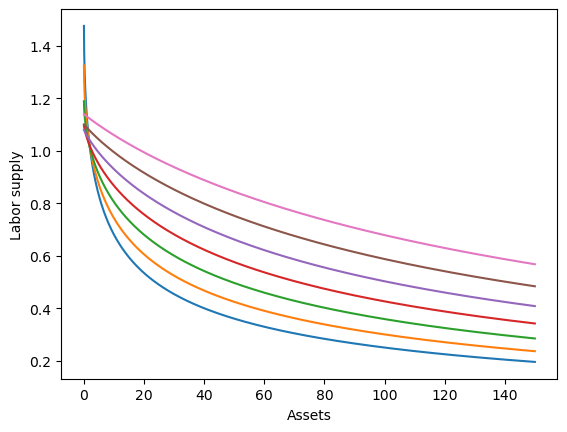

In [13]:
plt.plot(ss0.internals['hh']['a_grid'], ss0.internals['hh']['n'].T)
plt.xlabel('Assets'), plt.ylabel('Labor supply')
plt.show()

In [14]:
ss0.internals['hh']['n'].shape

(7, 500)

## 4 Linearized dynamics using Jacobians
Recall that we reduced the model to an implicit equation
$$
H(\pi, Y, w; r^*, Z) =
\begin{pmatrix}
\kappa \left(\frac{w_t}{Z_t} - \frac{1}{\mu} \right)  + \frac{1}{1+r_{t+1}} \frac{Y_{t+1}}{Y_t} \log(1+\pi_{t+1}) - \log(1+\pi_t)
\\
\mathcal{A}_t(\{r_s, w_s, \tau_s, d_s\})  - B
\\
\mathcal{L}_t(\{r_s, w_s, \tau_s, d_s\}) - L_t
\end{pmatrix}
= \begin{pmatrix} 0 \\ 0 \\ 0\end{pmatrix},
$$

to be solved for $U=(\pi, w, Y)$ given any $Z=(Z, r^*)$. The rest of the endogenous variables are be obtained as explicit functions of $(\pi, w, Y; Z, r^*)$ along the DAG, but it would be tedious to write them out.

Keep in mind that the implicit function theorem implies that the response of unknowns is

$$
dU = \underbrace{-H_U^{-1}H_Z}_{G_U} dZ \tag{1}
$$

Recall that we already solved for a steady state and stored is as `ss`. Furthermore, we will use a 300-period truncation horizon. 

### 4.1 Set up the DAG

Let's set up the second (main) DAG. We just have to replace `nkpc_ss` with a full Phillips curve.

In [15]:
@simple
def nkpc(pi, w, Z, Y, r, mu, kappa):
    nkpc_res = kappa * (w / Z - 1 / mu) + Y(+1) / Y * (1 + pi(+1)).apply(np.log) / (1 + r(+1))\
               - (1 + pi).apply(np.log)
    return nkpc_res


blocks = [hh_ext, firm, monetary, fiscal, mkt_clearing, nkpc]
hank = create_model(blocks, name="One-Asset HANK")

print(*hank.blocks, sep='\n')

<SimpleBlock 'monetary'>
<SimpleBlock 'nkpc'>
<SimpleBlock 'fiscal'>
<SimpleBlock 'firm'>
<HetBlock 'hh' with hetinput 'make_grid_transfers' and with hetoutput `labor_supply'>
<SimpleBlock 'mkt_clearing'>


- Recall that `create_model` performs a topological sort to put the blocks in a (not necessarily unique) correct order of evaluation. Here, `monetary` must be first, then `nkpc`, `fiscal`, `firm` in any order, then `hh`, and finally `mkt_clearing`. Note that `hank.blocks` is a list in such an order.

Before we proceed, let's make sure that `ss0` is consistent with the second DAG. Just evaluate the `hank` at `ss0` and verify that the equilibrium conditions hold as expected.

In [16]:
ss = hank.steady_state(ss0)

for k in ss0.keys():
    assert np.all(np.isclose(ss[k], ss0[k]))

### 4.2 Obtain GE Jacobian 

With the model object `hank` in hand, we can get the general equilibrium Jacobians by using its `solve_jacobian` method.

In [17]:
# setup
T = 300
exogenous = ['rstar', 'Z']
unknowns = ['pi', 'w', 'Y']
targets = ['nkpc_res', 'asset_mkt', 'labor_mkt']

# general equilibrium jacobians
G = hank.solve_jacobian(ss, unknowns, targets, exogenous, T=T)

print(G)

<JacobianDict outputs=['pi', 'w', 'Y', 'A', 'C', 'N', 'NE', 'L', 'Div', 'r', 'Tax', 'asset_mkt', 'labor_mkt', 'goods_mkt', 'nkpc_res'], inputs=['rstar', 'Z']>


Under the hood, the `solve_jacobian` method performs the following steps:
 - computes the partial Jacobians $\mathcal{J}^{o,i}$ for all blocks (if their Jacobian is not supplied already), only with respect to the inputs that actually change: unknowns, exogenous shocks, outputs of earlier blocks
 - forward accumulates partial Jacobians $\mathcal{J}^{o,i}$ to form total Jacobians $\mathbf{J}^{o,i}$
 - packs $\mathbf{J}^{o,i}$ to form $\mathbf{H_U}$ and $\mathbf{H_Z}$
 - solves for the GE Jacobians for unknowns $\mathbf{G_U} = \mathbf{H_U}^{-1}\mathbf{H_Z}$
 - forward accumulates GE Jacobians to obtain $\mathbf{G}$ for other endogenous variables 

# Modifications 

### 4.3 Results

Now let's consider 25 basis point (<span style="color:red;">contractionary</span>) monetary policy shocks with different persistences and plot the response of inflation.

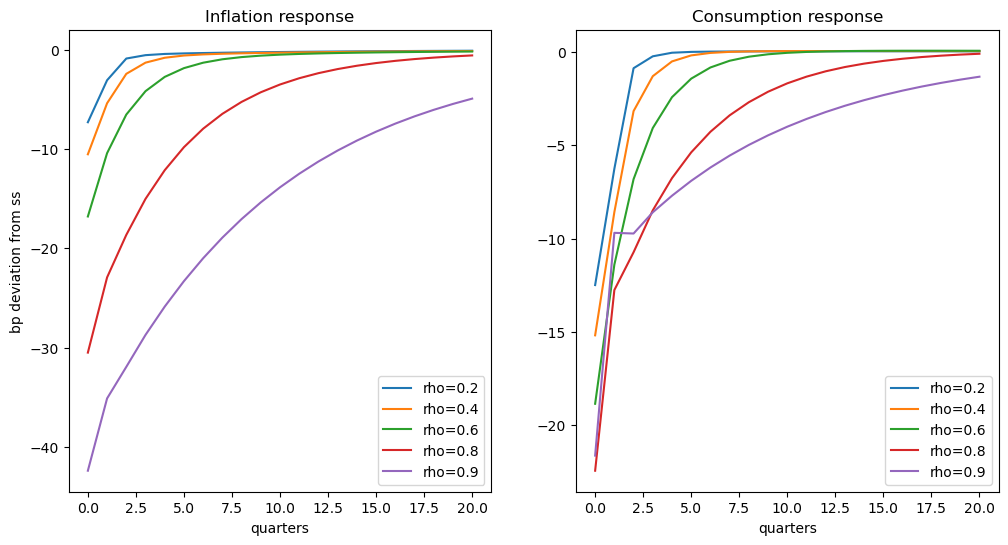

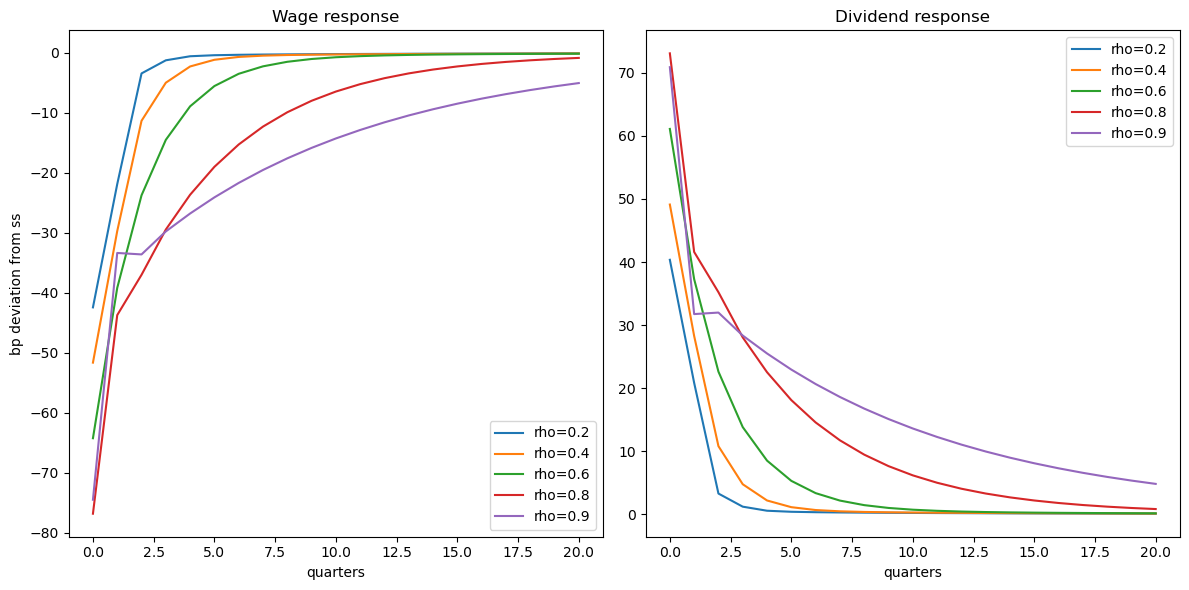

In [68]:
import matplotlib.pyplot as plt
import numpy as np

rhos = np.array([0.2, 0.4, 0.6, 0.8, 0.9])

drstar = 0.0025 * rhos ** (np.arange(T)[:, np.newaxis])
dpi = 10000 * G['pi']['rstar'] @ drstar
dci = 10000 * G['C']['rstar'] @ drstar
ddi = 10000 * G['Div']['rstar'] @ drstar
dwi = 10000 * G['w']['rstar'] @ drstar

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for rho_value in rhos:
    plt.plot(dpi[:21, rhos.tolist().index(rho_value)], label=f'rho={rho_value}')
plt.title(r'Inflation response')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.legend()

plt.subplot(1, 2, 2)
for rho_value in rhos:
    plt.plot(dci[:21, rhos.tolist().index(rho_value)], label=f'rho={rho_value}')
plt.title('Consumption response')
plt.xlabel('quarters')
plt.legend()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for rho_value in rhos:
    plt.plot(dwi[:21, rhos.tolist().index(rho_value)], label=f'rho={rho_value}')
plt.title(r'Wage response')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.legend()

plt.subplot(1, 2, 2)
for rho_value in rhos:
    plt.plot(ddi[:21, rhos.tolist().index(rho_value)], label=f'rho={rho_value}')
plt.title('Dividend response')
plt.xlabel('quarters')
plt.legend()

plt.tight_layout()
plt.show()

Implication: as we increase the persistence of a MP shock, the marginal effect on the change in inflation becomes increasingly higher than the m.e on consumption (note: not shown but the same implication holds for expansionary shock). 

Another interesting point is the massive (relative to inflation and consumption) responses we see to real wages and dividends -- this seems highly counterfactual. It's important to note that some of the authors of this toolbox seperately advocate for wage rigities instead of price rigities (shown here) when using HANK

Overall, we can use the Firm side to try to make sense of some of these effects 

$$\log(1 + \pi_t) = \kappa \left( \frac{w_t}{F'(N_t)} - \frac{1}{\mu} \right) + \frac{1}{1 + r_{t+1}} \frac{Y_{t+1}}{Y_t} \log(1 + \pi_{t+1})$$

$$d_t = Y_t - w_tN_t - \psi_t, \ \psi_t = \gamma \log(1+\pi_t)^2 Y_t$$

Given that the difference between output and consumption response is very small and inflation is 0 at the steady state, $Y_t - \psi_t \downarrow$. So the fall in wage expinditures accounts for the large rise in dividends. 

Additionally, we are simulating a shock to $r_t$ here, which in the context of the Firm's problem is the discount rate for future profits. Just as (all else equal) a higher $\rho$ (rate of time preference) on the household side implies a higher interest rate for the same savings motive, a higher interest rate implies future profit is discounted more. 

This structure implies inflation is pinned down by future marginal payoffs. That is, the marginal cost of changing price today must equal to the discounted sum of extra payoff in the future. This is a deterministic model, so following a one-time shock Firms have perfect foresight of what will happen in the future. Going back to the point on persistence, firms have a competing motive: a more persistent shock implies longer stretches of non-trivial markup/marginal cost deviations (and therefore want to change prices a lot immediately to minimize future adjustment costs) but it also reduces how much firm's care about incurring future costs (justifying a less intense initial adjustment). However, we see here the effect of the former dominates as persistence grows.  

The other equations that pin down a GE solution are market clearing (WLOG asset and labor). Therefore, the fixed supply assumption for assets will turn out to be critical. Because the return on saving has been changed but the change in saving must net out to 0, other parts must move around to accomodate this. Consider the following: if firm's are not allowed to adjust their price on impact, this would imply wages are constant. Household optimality implies they would supply the same amount of labor, which means output and therefore consumption and dividends (no adjustment costs) are unchanged. Because assets are in fixed supply, the above scenario is impossible.


## 5. Nonlinear dynamics

### 5.1 A typical monetary policy shock
Fully solving the model can let us see what's going on with the agents themselves.

Note that the linearized solution ignores price adjustment costs. For a monetary policy shock of typical size, this does not really matter. <span style="color:red;">Note</span> : different degrees of persistence (for a typical size) have negligible accuracy effects. For more discussion on the accuracy element, see the original notebook in the SSJ repository. 

Since the runtime is quite fast, we use the nonlinear model from here on out for completeness. We'll look at both a contractionary and expansionary MP suprise of typical size and persistence. 

In [ ]:
rho_r, sig_r = 0.61, 0.01/4
rstar_shock_path = {"rstar": sig_r * rho_r ** (np.arange(T))}
Erstar_shock_path = {"rstar": -sig_r * rho_r ** (np.arange(T))}

td_nonlin = hank.solve_impulse_nonlinear(ss, unknowns, targets, rstar_shock_path,internals=['hh'])
Etd_nonlin = hank.solve_impulse_nonlinear(ss, unknowns, targets, Erstar_shock_path,internals=['hh'])

As we said, the asset is fixed supply. But of course, a monetary policy shock will have effects on individual household's savings decisions, even if the net effects are zero. 

Let's call $a^*$ the optimal choice of assets in the steady state and $a_0$ the choice after a shock to rates at 0. A relevant question is what is the (unconditional)  likelihood an agent decides to save more. That is, $\mathbb{P}(a^*>a_0)$. It also may be of interest to decompose this based on their current wealth an skill level. 

Interestingly, many more agents (just in terms of volume) decide to save when there is an unexpected _cut_ to interest rates. 

Note: while the initial statistic is probability weighted, the below table looks are pure (relative) frquencies on the grid and does not account for the distribution because there are inherently more members of the population in the middle of the wealth and distribution. In other words, there are 7x500 possible places for a household to be. We look at how many of these places the policy function for assets has increased, and where those places are on the grid. 

In [121]:
# 'a' internals -- change in policy function for someone at a given point in asset grid 
# 'Dbeg' ss0 -- probability distribution of agents at asset grid at steady state 
pop= (td_nonlin.internals['hh']['a'][0,:,:] >= 0).astype(int)
alta = (Etd_nonlin.internals['hh']['a'][0,:,:] >= 0).astype(int)
results = {}
for j in range(7):
    sums_j = np.sum(pop[j, :])
    bors = np.sum(pop[j, :248])
    savs = sums_j - bors
    cum_freq = 100 * sums_j / np.sum(alta)
    borrower_percent = 100 * bors / sums_j if sums_j != 0 else 0  
    savers_percent = 100 * savs / sums_j if sums_j != 0 else 0  
    
    results[j] = {
        'Borrower %': borrower_percent,
        'Savers %': savers_percent,
        'Cum Freq': cum_freq
    }

print("Interest Rate HIKE: ", f"{round(100*np.sum(ss0.internals['hh']['Dbeg'] * pop, axis=(0, 1)),1)}%", "save more than they would have")
print(" j | Borrower %    | Savers %     | Cum Freq")
print("-------------------------------------------------")
for j, data in results.items():
    bor_percent = f"{data['Borrower %']:.2f}%".rjust(12)
    sav_percent = f"{data['Savers %']:.2f}%".rjust(12)
    cum_freq = f"{data['Cum Freq']:.2f}%".rjust(10)
    print(f"{str(j).rjust(2)} | {bor_percent} | {sav_percent} | {cum_freq}")
print("-------------------------------------------")
print("\n")
for j in range(7):
    sums_j = np.sum(alta[j, :]*)
    bors = np.sum(alta[j, :248])
    savs = sums_j - bors
    cum_freq = 100 * sums_j / np.sum(alta)
    borrower_percent = 100 * bors / sums_j if sums_j != 0 else 0  
    savers_percent = 100 * savs / sums_j if sums_j != 0 else 0  
    
    results[j] = {
        'Borrower %': borrower_percent,
        'Savers %': savers_percent,
        'Cum Freq': cum_freq
    }
print(" Interest Rate CUT: ", f"{round(100*np.sum(ss0.internals['hh']['Dbeg'] * alta, axis=(0, 1)),1)}%", "save more than they would have")
print(" j | Borrower %    | Savers %     | Cum Freq")
print("-------------------------------------------------")
for j, data in results.items():
    bor_percent = f"{data['Borrower %']:.2f}%".rjust(12)
    sav_percent = f"{data['Savers %']:.2f}%".rjust(12)
    cum_freq = f"{data['Cum Freq']:.2f}%".rjust(10)
    print(f"{str(j).rjust(2)} | {bor_percent} | {sav_percent} | {cum_freq}")

Interest Rate HIKE:  44.6% save more than they would have
 j | Borrower %    | Savers %     | Cum Freq
-------------------------------------------------
 0 |       97.15% |        2.85% |      1.92%
 1 |       93.95% |        6.05% |     10.33%
 2 |       82.87% |       17.13% |     18.95%
 3 |        6.21% |       93.79% |     10.28%
 4 |        0.00% |      100.00% |     11.35%
 5 |        0.00% |      100.00% |      6.54%
 6 |        0.00% |      100.00% |      1.38%
-------------------------------------------


 Interest Rate CUT:  73.3% save more than they would have
 j | Borrower %    | Savers %     | Cum Freq
-------------------------------------------------
 0 |      100.00% |        0.00% |      8.85%
 1 |      100.00% |        0.00% |     10.54%
 2 |      100.00% |        0.00% |     12.28%
 3 |      100.00% |        0.00% |     14.14%
 4 |       89.53% |       10.47% |     16.12%
 5 |       80.00% |       20.00% |     18.04%
 6 |       72.09% |       27.91% |     20.02%


With a surprise hike: savers more likely to increase their savings and people of low type are more likely to save. Moreover, because the condition to form this table is a weak inequality, this also means borrowers borrow _more_. 

With a surprise cut, everything is opposite. Borrowers borrow less, savers save less, and people of high type are more likely to save. 

All relationships above are monotonic (in the respective parameter) and also symmetric for a rate and a cut. Only thinking about the fact that aggregate (and equillibrium) object movements also mirror each other, this makes sense. 

To unpack this a little more, the results in the hike case apply when households are also faced with lower wages (and higher dividends). Note that almost all households get more income from dividends then wages, and on average they get _a lot_ more (before and after the shock, $\mathbb{E}\left[ \frac{w}{Div+w}\right]=97.7%$ ). Given that most agents have trivial or negative asset holdings, it shouldn't be in retrospect more than moderately suprising that real incomes rise after a monetary shock for a measly .5% of the population. This accounts for the overall savings behavior. When thinking about type, since types have a degree of persistence, we can infer that the reason the only high(er) type households that save are current savers is because they do not expect their wage to see a dramatic cut in the future ("make hay while sun is shining" dominates). On the flipside, high type households that are current borrowers all categorically choose to go further into debt presumably because they expect their wages to rise (relative to today), meaning they can pay back debt later and borrow today to offset the income shock. 

In [117]:
#fact check on "before and after the shock"
wa = ss0.internals['hh']['ne']*ss0['w']
div = ss0.internals['hh']['D']
round(100*np.sum((ss0.internals['hh']['Dbeg'] * (wa/(wa+div))), axis=(0, 1)),1)-round(100*np.sum((ss0.internals['hh']['Dbeg'] * ((wa+td_nonlin['w'][0])/(wa+td_nonlin['w'][0]+div+td_nonlin.internals['hh']['D'][0]))), axis=(0, 1)),1)

0.0

In [118]:
#fact check on low volume of people gaining income 
incss = wa+div + (1+ss0['r'])*ss0.internals['hh']['a_grid']
inch = wa-td_nonlin['w'][0]+div-td_nonlin.internals['hh']['D'][0] + (1+td_nonlin['r'][0])*ss0.internals['hh']['a_grid']
pop= (inch-incss >= 0).astype(int)
round(np.sum(ss0.internals['hh']['Dbeg'] * pop, axis=(0, 1)),1)


0.5